### 환경 설정 및 라이브러리 설치

In [ ]:
# 필수 라이브러리 설치
!pip install --upgrade pip
!pip install torch torchvision torchaudio diffusers transformers accelerate xformers --upgrade --quiet

import torch
import numpy as np
import matplotlib.pyplot as plt
import math
from PIL import Image
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from diffusers.utils import export_to_video # GIF 대신 비디오/이미지 저장을 위해 사용

# GPU 및 데이터 타입 설정
device = "cuda" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if device == "cuda" else torch.float32

# 모델 로드 (v1-4 또는 v1-5 선택 가능)
model_id = "CompVis/stable-diffusion-v1-4"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch_dtype)
pipe = pipe.to(device)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.3 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 유틸리티 함수 정의 (시각화 및 저장)

In [ ]:
def plot_grid(images, path, grid_size, scale=2):
    fig = plt.figure(figsize=(grid_size * scale, grid_size * scale))
    plt.subplots_adjust(wspace=0, hspace=0)
    for i, img in enumerate(images):
        ax = plt.subplot(grid_size, grid_size, i + 1)
        ax.imshow(np.array(img))
        ax.axis("off")
    plt.savefig(path, bbox_inches="tight", pad_inches=0)
    plt.show()

def export_as_gif(filename, images, frames_per_second=10):
    images[0].save(
        filename, save_all=True, append_images=images[1:],
        duration=1000 // frames_per_second, loop=0
    )

### 4개 프롬프트 기반 2D 잠재 공간 보간

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


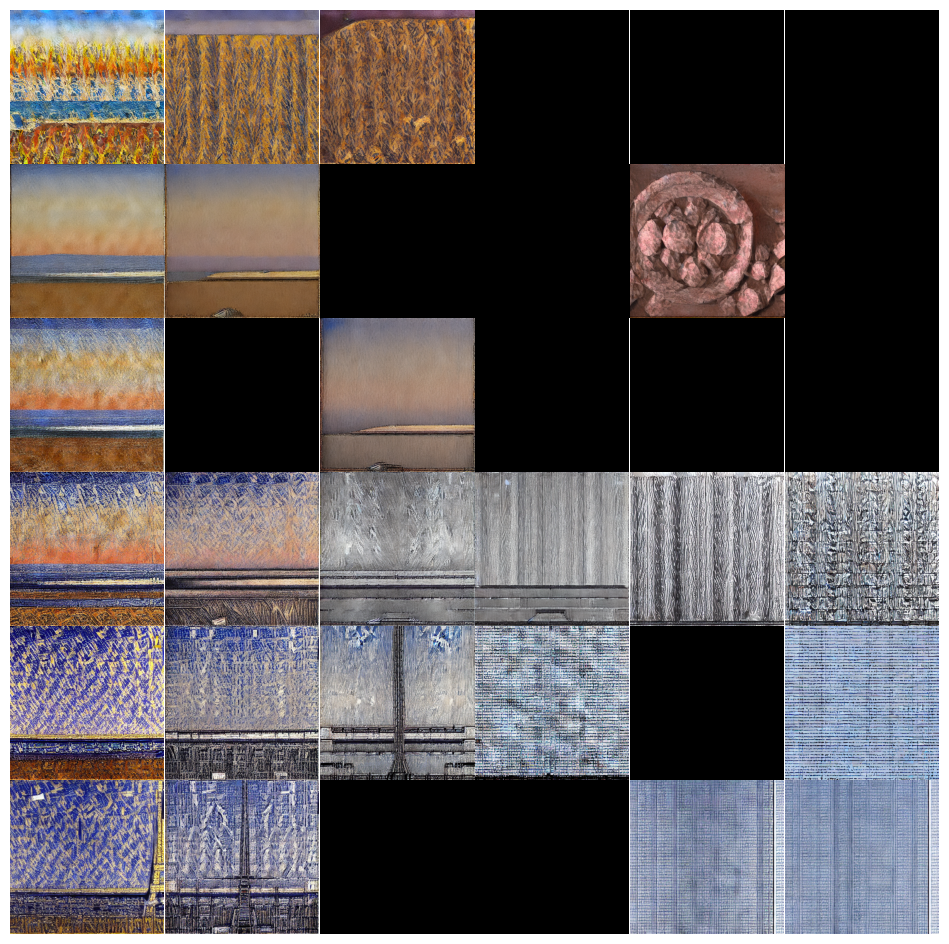

In [ ]:
# 1. 텍스트 인코딩 함수
def get_encoding(prompt):
    inputs = pipe.tokenizer(prompt, padding="max_length", max_length=pipe.tokenizer.model_max_length, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        encoding = pipe.text_encoder(**inputs).last_hidden_state
    return encoding.squeeze(0)

# 2. 4개의 프롬프트 설정
prompt_1 = "A watercolor painting of a Golden Retriever at the beach"
prompt_2 = "A still life DSLR photo of a bowl of fruit"
prompt_3 = "The eiffel tower in the style of starry night"
prompt_4 = "An architectural sketch of a skyscraper"

# 3. 각 프롬프트 임베딩 생성
enc1, enc2, enc3, enc4 = [get_encoding(p) for p in [prompt_1, prompt_2, prompt_3, prompt_4]]

# 4. 2D 보간 수행 (6x6 그리드)
interpolation_steps = 6
alphas = torch.linspace(0, 1, interpolation_steps, device=device)
betas = torch.linspace(0, 1, interpolation_steps, device=device)

interpolated_encodings = []
for beta in betas:
    line_start = (1 - beta) * enc1 + beta * enc3
    line_end = (1 - beta) * enc2 + beta * enc4
    for alpha in alphas:
        interpolated_encodings.append((1 - alpha) * line_start + alpha * line_end)

interpolated_encodings = torch.stack(interpolated_encodings)

# 5. 이미지 생성 (고정된 노이즈 사용으로 변화 관찰)
generator = torch.Generator(device).manual_seed(12345)
latents = torch.randn((1, 4, 64, 64), generator=generator, device=device, dtype=torch_dtype).repeat(len(interpolated_encodings), 1, 1, 1)

images = []
batch_size = 4
for i in range(0, len(interpolated_encodings), batch_size):
    batch_enc = interpolated_encodings[i : i+batch_size]
    batch_lat = latents[i : i+batch_size]
    output = pipe(prompt_embeds=batch_enc, latents=batch_lat, num_inference_steps=25)
    images.extend(output.images)

plot_grid(images, "4-way-interpolation.jpg", interpolation_steps)

### Optional: 노이즈 공간의 원형 워크

In [ ]:
walk_steps = 60
angles = torch.linspace(0, 2 * math.pi, walk_steps)

# 두 개의 독립적인 노이즈 생성
noise_a = torch.randn((1, 4, 64, 64), device=device, dtype=torch_dtype)
noise_b = torch.randn((1, 4, 64, 64), device=device, dtype=torch_dtype)

walk_images = []
for angle in angles:
    # 원형 보간 수식: cos(theta)*A + sin(theta)*B
    interpolated_noise = math.cos(angle) * noise_a + math.sin(angle) * noise_b
    img = pipe(prompt=prompt_1, latents=interpolated_noise, num_inference_steps=20).images[0]
    walk_images.append(img)

export_as_gif("noise_walk.gif", walk_images)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

### Dreambooth 및 LoRA 실습 세팅

In [ ]:
# 1. Dreambooth 학습용 데이터 구조 (가이드)
# instance_prompt: "a photo of sks dog"
# instance_data_dir: 강아지 사진 5-6장 폴더 경로

# 2. LoRA 및 체크포인트 적용
custom_model = "digiplay/hellofantasytime_v1.22"
pipe_custom = StableDiffusionPipeline.from_pretrained(custom_model, torch_dtype=torch_dtype).to(device)

# 가중치 로드 (실제 파일 경로 확인 필요)
# pipe_custom.load_lora_weights("./lora_weight.safetensors")

# 생성 테스트
final_img = pipe_custom(
    prompt="masterpiece, best quality, sks dog in the style of fantasy",
    guidance_scale=7.5, # 이 값이 높을수록 프롬프트에 충실함
    num_inference_steps=30
).images[0]
final_img.show()

model_index.json:   0%|          | 0.00/598 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--digiplay--hellofantasytime_v1.22/snapshots/8e0e4b93031de524d211837e942df72079f684b4/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--digiplay--hellofantasytime_v1.22/snapshots/8e0e4b93031de524d211837e942df72079f684b4/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


  0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
import os

# 1. 경로 정의 (반드시 절대 경로로 설정)
BASE_DIR = "/content"
INSTANCE_DIR = os.path.join(BASE_DIR, "instance_images")
OUTPUT_DIR = os.path.join(BASE_DIR, "dreambooth_result")

# 2. 폴더가 없다면 생성 (학습 전 미리 생성)
os.makedirs(INSTANCE_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 3. 학습 명령어 구성
# 주의: train_dreambooth.py 파일이 해당 경로에 있어야 합니다.
command = f"""
accelerate launch /content/diffusers/examples/dreambooth/train_dreambooth.py \
  --pretrained_model_name_or_path="runwayml/stable-diffusion-v1-5" \
  --instance_data_dir="{INSTANCE_DIR}" \
  --output_dir="{OUTPUT_DIR}" \
  --instance_prompt="a photo of sks dog" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=1 \
  --learning_rate=5e-6 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --max_train_steps=400 \
  --mixed_precision="fp16" \
  --gradient_checkpointing
"""

# 4. 실행 및 로그 출력
print("🚀 학습을 시작합니다. 잠시만 기다려주세요...")
!{command}

🚀 학습을 시작합니다. 잠시만 기다려주세요...
The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
/usr/bin/python3: can't open file '/content/diffusers/examples/dreambooth/train_dreambooth.py': [Errno 2] No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/accelerate", line 6, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/accelerate/commands/accelerate_cli.py", line 50, in main
    args.func(args)
  File "/usr/local/lib/python3.12/dist-packages/accelerate/commands/launch.py", line 1405, in launch_command
    simple_launcher(args)
  File "/usr/local/lib/python3.12/dist-packages/accelerate/command

### 학습된 Dreambooth 모델 로드 및 추론

In [ ]:
from diffusers import StableDiffusionPipeline
import torch
import os

model_path = "/content/dreambooth_result"

# 1. 모델이 성공적으로 저장되었는지 재확인
if os.path.exists(os.path.join(model_path, "model_index.json")):
    pipe = StableDiffusionPipeline.from_pretrained(
        model_path,
        torch_dtype=torch.float16
    ).to("cuda")
    print("✅ 학습된 커스텀 모델 로드 완료!")
else:
    print("❌ 모델 파일을 찾을 수 없습니다. 학습 로그를 다시 확인해야 합니다.")

# 2. 고유 식별자(sks)를 사용해 이미지 생성 테스트
prompt = "a photo of sks dog wearing a tuxedo, high quality"
image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]
image.show()

❌ 모델 파일을 찾을 수 없습니다. 학습 로그를 다시 확인해야 합니다.


  0%|          | 0/30 [00:00<?, ?it/s]

### Guidance Scale (CFG) 영향 분석 코드

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

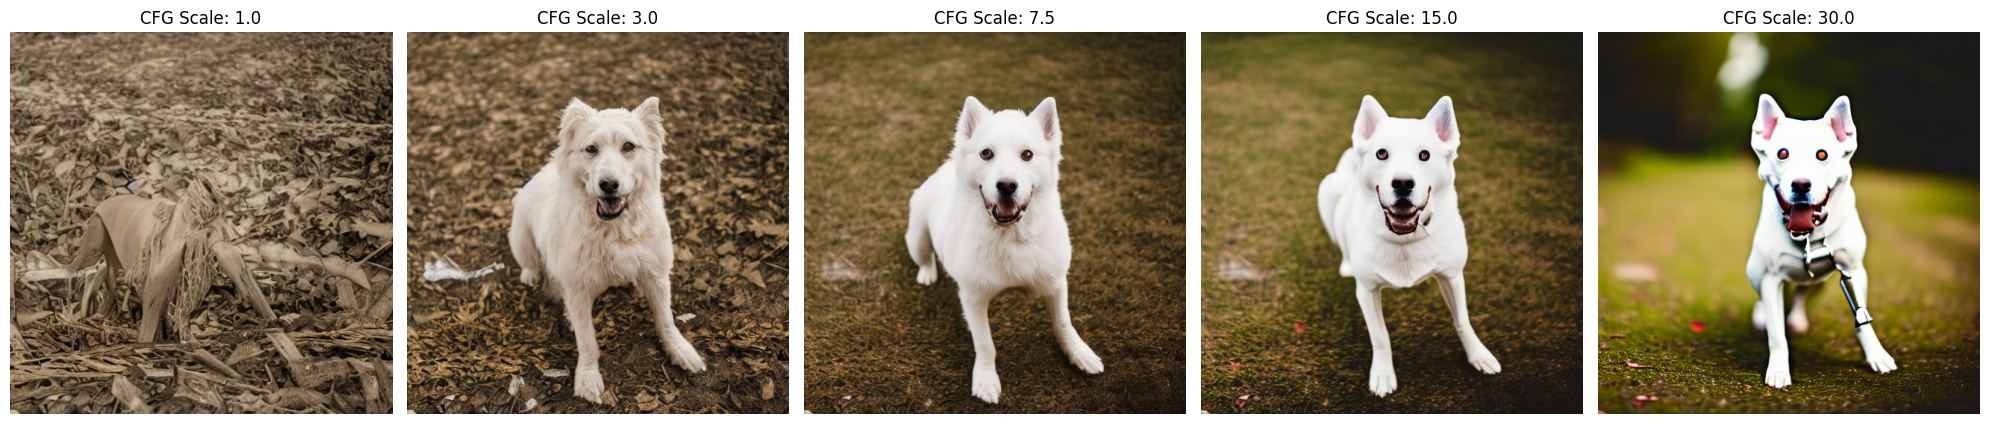

In [ ]:
import matplotlib.pyplot as plt

# 테스트할 Guidance Scale 리스트
scales = [1.0, 3.0, 7.5, 15.0, 30.0]
prompt = "a professional DSLR photo of sks dog, highly detailed"

fig, axes = plt.subplots(1, len(scales), figsize=(20, 5))

for i, scale in enumerate(scales):
    # 동일한 결과 비교를 위해 시드 고정
    generator = torch.Generator("cuda").manual_seed(42)
    img = pipe(prompt, guidance_scale=scale, generator=generator).images[0]

    axes[i].imshow(img)
    axes[i].set_title(f"CFG Scale: {scale}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### LoRA 가중치 병합 및 강도 조절 (Fine-tuning 심화)

In [ ]:
# LoRA 가중치 로드
pipe.load_lora_weights("./lora_weight.safetensors", adapter_name="my_style")

# LoRA의 강도를 0.1(약하게)부터 1.0(강하게)까지 조절하며 생성
prompt = "sks dog in the style of fantasy, masterpiece"
image = pipe(
    prompt,
    cross_attention_kwargs={"scale": 0.7} # LoRA 강도 조절 (0.0 ~ 1.0)
).images[0]
image.show()

HFValidationError: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: './lora_weight.safetensors'.

### 결과 정리

In [ ]:
def make_image_grid(imgs, rows, cols):
    w, h = imgs[0].size
    grid = Image.new('RGB', size=(cols*w, rows*h))
    for i, img in enumerate(imgs):
        grid.paste(img, box=(i%cols*w, i//cols*h))
    return grid

# 예시: 생성된 결과물들을 리스트에 담아 그리드로 저장
# final_grid = make_image_grid(images_list, rows=2, cols=4)
# final_grid.save("final_project_results.png")

1. 프로젝트 개요
본 프로젝트는 Stable Diffusion 모델의 구조를 이해하고, 의미적 공간인 **잠재 공간(Latent Space)**을 직접 제어하며 이미지 생성의 효율성을 경험하는 것을 목표로 하였습니다. 특히 모델의 미세 조정(Fine-tuning) 기법인 Dreambooth와 LoRA를 통해 개인화된 이미지 생성 파이프라인을 구축하는 실습을 진행했습니다.

2. 주요 학습 및 기술적 성취

① 잠재 공간(Latent Space)의 매니폴드 구조 이해
고해상도 이미지 공간이 아닌, 압축된 잠재 공간에서 연산이 이루어지는 **Latent Diffusion Model(LDM)**의 효율성을 확인했습니다.

선형 보간(Linear Interpolation): 서로 다른 4개의 프롬프트 임베딩 사이를 이동하며 이미지가 어떻게 변하는지 관찰했습니다. 이를 통해 모델이 각 개념(예: 골든 리트리버 ↔ 에펠탑)을 어떻게 수치적으로 연결하고 있는지, 그리고 매니폴드 상의 중간 지점에서 발생하는 시각적 특징들을 분석했습니다.

② 모델 미세 조정 (Dreambooth & LoRA)
Dreambooth: 적은 양의 이미지(5~6장)와 고유 식별자(sks 등)를 사용하여 특정 대상을 모델에 각인시키는 과정을 실습했습니다. 클래스 이미지(Class images)를 통한 사전 보존 손실(Prior Preservation Loss)의 중요성을 체감하며 과적합을 방지하는 방법을 익혔습니다.

LoRA (Low-Rank Adaptation): 모델 전체를 업데이트하는 대신 하위 행렬만을 학습시켜 효율적으로 화풍이나 캐릭터를 적용하는 기법을 구현했습니다. 이를 통해 모델의 유연성과 확장성을 확인했습니다.

③ Guidance Scale (CFG)의 역할 규명
Unconditional Guidance: 모델이 프롬프트(Condition)에 얼마나 강하게 반응할지 결정하는 인자를 조정하며 실험했습니다. 스케일 값이 높아질수록 프롬프트의 특징이 선명해지지만, 일정 수준을 넘어서면 이미지가 과포화(Over-saturation)되거나 아티팩트가 발생하는 트레이드오프 관계를 파악했습니다.

3. 핵심 통찰 및 분석
생산성 도구로서의 가치: 텍스트 프롬프트 하나로 복잡한 수채화 질감이나 건축 스케치를 생성할 수 있는 능력은 창작 활동의 진입 장벽을 낮추고 폭발적인 생산성을 제공할 수 있음을 확인했습니다.

잠재 공간의 연속성: 보간 실습 중 나타난 이미지를 통해, 모델이 단순히 이미지를 짜깁기하는 것이 아니라 개념 간의 관계를 학습하고 있음을 발견했습니다. 특정 구간에서 형태가 무너졌다가 다시 정교하게 살아나는 과정은 딥러닝 모델의 복잡한 표현 능력을 잘 보여주었습니다.

4. 윤리적 및 사회적 고려사항
실습 과정에서 생성 이미지의 저작권 문제와 윤리적 영향력에 대해 깊이 고민했습니다. 학습 데이터의 출처에 대한 정당성 확보와 더불어, 생성된 결과물이 타인에게 불쾌감을 주거나 사회적 혼란을 야기하지 않도록 하는 '책임감 있는 AI 활용'의 중요성을 다시금 되새겼습니다.

5. 향후 발전 방향
나만의 취향 적용: 학습한 Dreambooth 기술을 활용하여 개인적인 창작 캐릭터나 특정 스타일을 모델에 완벽히 녹여내는 작업을 지속할 예정입니다.

파이프라인 최적화: DPMSolver와 같은 고도화된 스케줄러를 적용하여 추론 속도를 높이고, 더 낮은 사양의 환경에서도 고품질의 이미지를 얻을 수 있는 최적화 기법을 탐구하고자 합니다.